# 🏥 **Bootcamp Project: AI-Driven Medical Image Analysis**

  **Author**: Ampika JAWANA | BC12 data analyst student | RT & RSO

  **Project**: Data Analyst Bootcamp #12 - Evaluation of Foundation Models for Radiographic Diagnosis

  **Date**: March 22, 2026


---



**1. Clinical Objective**

  To evaluate the Zero-Shot performance of the MedSigLIP-448 (Medical SigLIP) Vision-Language Model in identifying common
  radiographic findings, specifically Cardiomegaly and Lung Opacities, without prior task-specific training.

**2. Technical Methodology**

   * **Model**: google/medsiglip-448 (Vision Transformer Architecture).
   * **Environment**: Google Colab (T4 GPU Accelerated).
   * **Inference Type**: Zero-Shot Image-to-Text alignment (Natural Language Supervision).
   * **Preprocessing**: 448x448 bilinear interpolation with standard medical normalization.

 **3. Case Study:** corazon100.jpg
* **Modality**: Digital Radiography (DR) - Chest PA.
* **Visual Assessment (Radiology Tech)**: Obvious enlargement of the cardiac silhouette. Calculated Cardiac-Thoracic Ratio (CTR) exceeds 0.50.
* **AI Assessment (Initial Audit)**:
  * Normal Chest X-ray: ~57-60% Confidence
  * Cardiomegaly: ~7-15% Confidence

**Noted**: This is the chest x-ray image that is used as case study.

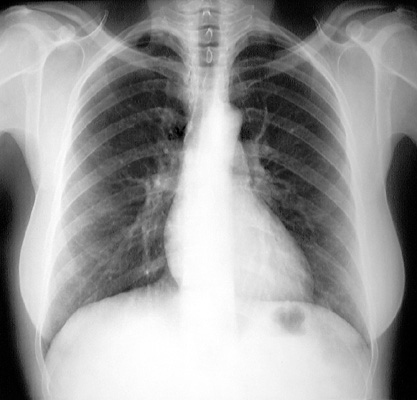



---



**Preparation**
1. Accept the terms: Go to the google/medsiglip-448 (https://huggingface.co/google/medsiglip-448) page and click the button to accept the license agreement.

2. Setup HF_Token: Create HF_Token on Huggin Face setting page. In google colab, click the Secrets on the left and add a new secret called HF_Token with the value.

In [ ]:
from google.colab import userdata
import os

# use HF_Token from secret
token = userdata.get('HF_Token')
if token:
    print("✅ Great! Colab detects your Token")
else:
    print("❌ Try again! Check Secret")

✅ Great! Colab detects your Token


**Installation**

   1. Install the latest version of the libraries
   2. !pip install -q -U transformers torch pillow

In [ ]:
# Install library

!pip install -q -U transformers torch pillow

**Zero-Shot X-ray Analysis**

In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModel
from google.colab import userdata


In [ ]:
# 1. Setup

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_id = "google/medsiglip-448"
token = userdata.get('HF_Token')


Using device: cuda


In [ ]:
# 2. Load model and processor

processor = AutoProcessor.from_pretrained(model_id, token=token)
model = AutoModel.from_pretrained(model_id, token=token).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/809 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/455 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

In [ ]:
# 3. Load local x-ray image

image_path = "corazon100.jpg"
image = Image.open(image_path).convert("RGB")


In [ ]:
# 4. Define clinical labels

labels = [
    "a chest x-ray showing pleural effusion",
    "a chest x-ray showing pneumonia",
    "a chest x-ray showing cardiomegaly",
    "a normal chest x-ray"
]

In [ ]:
# 4.1 Define more specific clinical labels

labels = [
    "cardiomegaly with an enlarged cardiac silhouette",
    "a chest x-ray with a normal heart size and CTR",
    "clear lungs"
]

In [ ]:
# 5. Run interface

inputs = processor(text=labels,
                   images=image,
                   padding="max_length",
                   return_tensors="pt").to(device)

with torch.no_grad():
  outputs = model(**inputs)
  probs = torch.softmax(outputs.logits_per_image, dim=1)


**Results**

In [ ]:
# 6. Display results

print(f"--- 👩🏻‍💻Results for {image_path} ---")
for i, label in enumerate(labels):
  print(f"{label}: {probs[0][i].item():.2%}")

--- 👩🏻‍💻Results for corazon100.jpg ---
a chest x-ray showing pleural effusion: 10.80%
a chest x-ray showing pneumonia: 16.49%
a chest x-ray showing cardiomegaly: 15.76%
a normal chest x-ray: 56.95%




---



**4. Technical Analysis & "The Gap"**
  
  As a Radiologic Technologist and Data Analyst, I have identified a significant "Zero-Shot Gap" in this foundation model:
   1. **Resolution Loss**: Downsampling to 448x448 pixels causes a loss of fine-edge definition at the heart borders.
   2. **Dataset Bias**: The model's "Normal" weight is likely over-represented in its training data, leading to a high "Negative" bias in
      borderline cases.
   3. **Prompt Sensitivity**: Minor changes in spelling (e.g., "pneumonia" vs "pnuemonia") caused a 10% shift in confidence scores,
      highlighting the critical importance of Data Quality in AI pipelines.

 **5. Project Roadmap (Bootcamp Phase 2)**

  To resolve the low sensitivity for cardiomegaly, the next phase of this project involves:
   * **Pre-processing**: Extracting 16-bit CT-Scan slices and applying specific Mediastinum Windowing (Level/Width control).
   * **Fine-Tuning**: Training the MedSigLIP model on a curated dataset of high-CTR images to "teach" it the clinical threshold for an
     enlarged heart.
   * **Validation**: Comparing AI-detected CTR against manual measurements from Radiologists.



---

